fetching 20 OSM tiles at zoom 12 ...
querying Overpass (https://maps.mail.ru/osm/tools/overpass/api/interpreter) ...
OSM features:  highway=408  railway=26  landuse=1268  leisure=345  building=9434  amenity=404


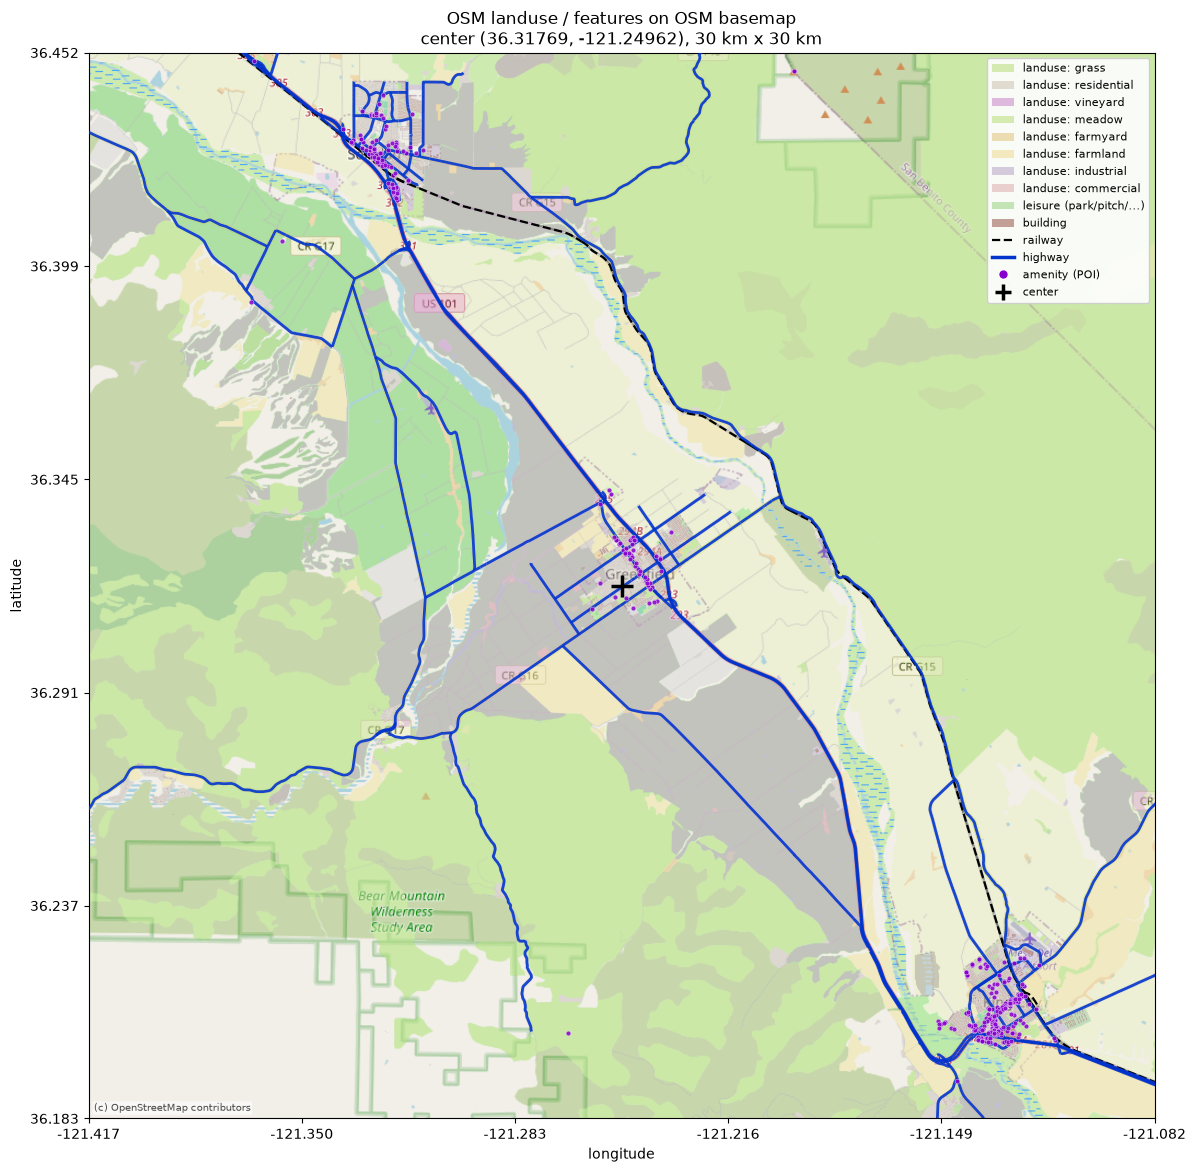

In [3]:
%matplotlib inline

import io
import json
import math
import sys
import urllib.parse
import urllib.request

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.collections import LineCollection, PatchCollection
from matplotlib.patches import Patch
from matplotlib.patches import Polygon as MplPolygon
from PIL import Image

# ----------------------------------------------------------------------------
# Hardcoded configuration
# ----------------------------------------------------------------------------
CENTER_LAT = 36.31769
CENTER_LON = -121.24962
BOX_KM = 30.0    # full width/height of the (square) window in km
ZOOM = 12        # OSM tile zoom level

# which OSM feature layers to draw (no clustering/settlement boxes here)
OSM_LAYERS = {
    "landuse": True,
    "leisure": True,
    "building": True,
    "amenity": True,
    "railway": True,
    "highway": True,
}

_KM_PER_DEG_LAT = 111.32
_R = 6378137.0   # Web Mercator sphere radius (m)
USER_AGENT = "countryside_map/1.0 (OSM landuse map demo)"
_HEADERS = {"User-Agent": USER_AGENT}  # OSM tile server / Overpass reject requests without one


def http_get(url, timeout=30):
    """GET a URL with urllib and return the raw response bytes."""
    req = urllib.request.Request(url, headers=_HEADERS, method="GET")
    with urllib.request.urlopen(req, timeout=timeout) as resp:
        return resp.read()


def http_post_form(url, form, timeout=60):
    """POST a form-encoded body with urllib and return the raw response bytes."""
    body = urllib.parse.urlencode(form).encode("utf-8")
    req = urllib.request.Request(url, data=body, headers=_HEADERS, method="POST")
    with urllib.request.urlopen(req, timeout=timeout) as resp:
        return resp.read()


LANDUSE_COLORS = {
    "farmland": "#f3e4b0", "farmyard": "#e8d5a0", "vineyard": "#d7a8d7",
    "orchard": "#c6df9a", "residential": "#dcd2c6", "commercial": "#e6c6c6",
    "retail": "#e6afaf", "industrial": "#cdbdd6", "forest": "#a6cf96",
    "meadow": "#cbe69f", "grass": "#cbe69f", "cemetery": "#b3c49f",
    "recreation_ground": "#c2df9f", "quarry": "#c6bfb0",
}
LANDUSE_DEFAULT = "#d9d9d9"
LEISURE_COLORS = {
    "park": "#b3e096", "garden": "#b3e096", "nature_reserve": "#a0d488",
    "pitch": "#9bd6ab", "playground": "#e0d3ad", "golf_course": "#aede96",
}
LEISURE_DEFAULT = "#b9dea6"
BUILDING_COLOR = "#b98f86"
AMENITY_COLOR = "#8800cc"


# ----------------------------------------------------------------------------
# Web Mercator helpers
# ----------------------------------------------------------------------------
def merc(lon, lat):
    x = _R * math.radians(lon)
    y = _R * math.log(math.tan(math.pi / 4 + math.radians(lat) / 2))
    return x, y


def merc_arr(lons, lats):
    lons = np.asarray(lons, dtype="float64")
    lats = np.asarray(lats, dtype="float64")
    x = _R * np.radians(lons)
    y = _R * np.log(np.tan(np.pi / 4 + np.radians(lats) / 2))
    return x, y


def ring_to_merc(geometry):
    lons = [p["lon"] for p in geometry]
    lats = [p["lat"] for p in geometry]
    x, y = merc_arr(lons, lats)
    return np.column_stack([x, y])


def bbox_from_center(lat, lon, box_km):
    half = box_km / 2.0
    d_lat = half / _KM_PER_DEG_LAT
    d_lon = half / (_KM_PER_DEG_LAT * max(math.cos(math.radians(lat)), 1e-6))
    return lon - d_lon, lat - d_lat, lon + d_lon, lat + d_lat  # west, south, east, north


# ----------------------------------------------------------------------------
# OSM tile basemap
# ----------------------------------------------------------------------------
def _deg2num(lat, lon, n):
    x = (lon + 180.0) / 360.0 * n
    lat_r = math.radians(lat)
    y = (1.0 - math.asinh(math.tan(lat_r)) / math.pi) / 2.0 * n
    return x, y


def _num2lat(y, n):
    return math.degrees(math.atan(math.sinh(math.pi * (1.0 - 2.0 * y / n))))


def fetch_osm_basemap(west, south, east, north, zoom):
    """Download & stitch OSM tiles. Returns (image_array, mercator_extent)."""
    n = 2 ** zoom
    x_tl, y_tl = _deg2num(north, west, n)
    x_br, y_br = _deg2num(south, east, n)
    tx0, tx1 = int(math.floor(x_tl)), int(math.floor(x_br))
    ty0, ty1 = int(math.floor(y_tl)), int(math.floor(y_br))

    n_tiles = (tx1 - tx0 + 1) * (ty1 - ty0 + 1)
    print(f"fetching {n_tiles} OSM tiles at zoom {zoom} ...")

    canvas = Image.new("RGB", ((tx1 - tx0 + 1) * 256, (ty1 - ty0 + 1) * 256), (221, 221, 221))
    subdomains = ["a", "b", "c"]
    for tx in range(tx0, tx1 + 1):
        for ty in range(ty0, ty1 + 1):
            sub = subdomains[(tx + ty) % 3]
            url = f"https://{sub}.tile.openstreetmap.org/{zoom}/{tx}/{ty}.png"
            try:
                content = http_get(url, timeout=30)
                tile = Image.open(io.BytesIO(content)).convert("RGB")
                canvas.paste(tile, ((tx - tx0) * 256, (ty - ty0) * 256))
            except Exception as exc:  # noqa: BLE001 - leave gray tile on failure
                print(f"  tile {zoom}/{tx}/{ty} failed: {exc}", file=sys.stderr)

    lon_left = tx0 / n * 360.0 - 180.0
    lon_right = (tx1 + 1) / n * 360.0 - 180.0
    lat_top = _num2lat(ty0, n)
    lat_bot = _num2lat(ty1 + 1, n)
    x_left, y_top = merc(lon_left, lat_top)
    x_right, y_bot = merc(lon_right, lat_bot)
    return np.asarray(canvas), (x_left, x_right, y_bot, y_top)


# ----------------------------------------------------------------------------
# OSM vector features (Overpass) — no clustering, just the raw geometries
# ----------------------------------------------------------------------------
def fetch_osm_features(west, south, east, north, want, timeout=120):
    feats = {k: [] for k in ("highway", "railway", "landuse", "leisure",
                             "building", "amenity")}
    bbox = f"{south},{west},{north},{east}"
    parts = []
    if want.get("highway"):
        parts.append(f'way["highway"~"^(motorway|trunk|primary|secondary|tertiary)$"]({bbox});')
    if want.get("railway"):
        parts.append(f'way["railway"~"^(rail|light_rail|tram|subway|narrow_gauge)$"]({bbox});')
    if want.get("landuse"):
        parts.append(f'way["landuse"]({bbox});')
    if want.get("leisure"):
        parts.append(f'way["leisure"]({bbox});')
    if want.get("building"):
        parts.append(f'way["building"]({bbox});')
    if want.get("amenity"):
        parts.append(f'node["amenity"]({bbox});')
        parts.append(f'way["amenity"]({bbox});')
    if not parts:
        return feats

    query = f"[out:json][timeout:{timeout}];\n(\n  " + "\n  ".join(parts) + "\n);\nout geom;"
    endpoints = [
        "https://maps.mail.ru/osm/tools/overpass/api/interpreter",
        "https://overpass-api.de/api/interpreter",
        "https://overpass.kumi.systems/api/interpreter",
    ]
    data = None
    for url in endpoints:
        try:
            print(f"querying Overpass ({url}) ...")
            payload = http_post_form(url, {"data": query}, timeout=timeout + 30)
            data = json.loads(payload)
            break
        except Exception as exc:  # noqa: BLE001
            print(f"overpass {url} failed: {exc}", file=sys.stderr)
    if data is None:
        print("no OSM feature data retrieved", file=sys.stderr)
        return feats

    for el in data.get("elements", []):
        tags = el.get("tags", {})
        etype = el.get("type")
        if etype == "node" and "amenity" in tags:
            feats["amenity"].append((el["lon"], el["lat"], tags["amenity"]))
            continue
        if etype != "way" or "geometry" not in el:
            continue
        geom = el["geometry"]
        if "highway" in tags:
            feats["highway"].append((geom, tags.get("ref") or tags.get("name", "")))
        elif "railway" in tags:
            feats["railway"].append(geom)
        elif "building" in tags:
            feats["building"].append(geom)
        elif "landuse" in tags:
            feats["landuse"].append((geom, tags["landuse"]))
        elif "leisure" in tags:
            feats["leisure"].append((geom, tags["leisure"]))
        elif "amenity" in tags:
            lons = [p["lon"] for p in geom]
            lats = [p["lat"] for p in geom]
            feats["amenity"].append((sum(lons) / len(lons), sum(lats) / len(lats),
                                     tags["amenity"]))
    return feats


# ----------------------------------------------------------------------------
# Rendering helpers
# ----------------------------------------------------------------------------
def add_polygons(ax, items, color_of, zorder, alpha, edgecolor="none", lw=0.0):
    patches, facecolors = [], []
    for it in items:
        geom, value = it if isinstance(it, tuple) else (it, None)
        if len(geom) < 3:
            continue
        patches.append(MplPolygon(ring_to_merc(geom), closed=True))
        facecolors.append(color_of(value))
    if not patches:
        return
    ax.add_collection(PatchCollection(patches, facecolors=facecolors,
                                      edgecolors=edgecolor, linewidths=lw,
                                      alpha=alpha, zorder=zorder))


def setup_axes(ax, base_img, base_extent, west, south, east, north, title):
    ax.imshow(base_img, extent=base_extent, origin="upper", interpolation="bilinear",
              zorder=0)
    xw, yb = merc(west, south)
    xe, yt = merc(east, north)
    ax.set_xlim(xw, xe)
    ax.set_ylim(yb, yt)
    lon_ticks = np.linspace(west, east, 6)
    lat_ticks = np.linspace(south, north, 6)
    ax.set_xticks([merc(v, CENTER_LAT)[0] for v in lon_ticks])
    ax.set_xticklabels([f"{v:.3f}" for v in lon_ticks])
    ax.set_yticks([merc(CENTER_LON, v)[1] for v in lat_ticks])
    ax.set_yticklabels([f"{v:.3f}" for v in lat_ticks])
    ax.set_xlabel("longitude")
    ax.set_ylabel("latitude")
    ax.set_title(title)
    return (xw, yb, xe, yt)


def add_attribution(ax):
    ax.text(0.005, 0.005, "(c) OpenStreetMap contributors", transform=ax.transAxes,
            fontsize=7, color="black", alpha=0.7, ha="left", va="bottom",
            bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.6))


# ----------------------------------------------------------------------------
# Fetch inputs and draw the landuse / feature map (no clustering)
# ----------------------------------------------------------------------------
west, south, east, north = bbox_from_center(CENTER_LAT, CENTER_LON, BOX_KM)
base_img, base_extent = fetch_osm_basemap(west, south, east, north, ZOOM)
feats = fetch_osm_features(west, south, east, north, OSM_LAYERS)
print("OSM features:  " + "  ".join(f"{k}={len(v)}" for k, v in feats.items()))

fig, ax = plt.subplots(figsize=(12, 12))
setup_axes(ax, base_img, base_extent, west, south, east, north,
           f"OSM landuse / features on OSM basemap\n"
           f"center ({CENTER_LAT}, {CENTER_LON}), {BOX_KM:.0f} km x {BOX_KM:.0f} km")
handles = []

if OSM_LAYERS["landuse"] and feats["landuse"]:
    add_polygons(ax, feats["landuse"],
                 lambda v: LANDUSE_COLORS.get(v, LANDUSE_DEFAULT),
                 zorder=1, alpha=0.5)
    counts = {}
    for _, v in feats["landuse"]:
        counts[v] = counts.get(v, 0) + 1
    for v, _ in sorted(counts.items(), key=lambda kv: kv[1], reverse=True)[:8]:
        handles.append(Patch(facecolor=LANDUSE_COLORS.get(v, LANDUSE_DEFAULT),
                             edgecolor="none", alpha=0.8, label=f"landuse: {v}"))

if OSM_LAYERS["leisure"] and feats["leisure"]:
    add_polygons(ax, feats["leisure"],
                 lambda v: LEISURE_COLORS.get(v, LEISURE_DEFAULT),
                 zorder=1.3, alpha=0.6)
    handles.append(Patch(facecolor=LEISURE_DEFAULT, edgecolor="none",
                         alpha=0.8, label="leisure (park/pitch/...)"))

if OSM_LAYERS["building"] and feats["building"]:
    add_polygons(ax, feats["building"], lambda v: BUILDING_COLOR,
                 zorder=2, alpha=0.8)
    handles.append(Patch(facecolor=BUILDING_COLOR, edgecolor="none",
                         alpha=0.85, label="building"))

if OSM_LAYERS["railway"] and feats["railway"]:
    segs = [ring_to_merc(g) for g in feats["railway"] if len(g) >= 2]
    ax.add_collection(LineCollection(segs, colors="black", linewidths=1.6,
                                     linestyles="dashed", zorder=3))
    handles.append(plt.Line2D([], [], color="black", lw=1.6, ls="dashed",
                              label="railway"))

if OSM_LAYERS["highway"] and feats["highway"]:
    segs = [ring_to_merc(g) for g, _ in feats["highway"] if len(g) >= 2]
    ax.add_collection(LineCollection(segs, colors="#0033cc", linewidths=2.0,
                                     alpha=0.9, zorder=3.5))
    handles.append(plt.Line2D([], [], color="#0033cc", lw=2.5, label="highway"))

if OSM_LAYERS["amenity"] and feats["amenity"]:
    alon = np.array([a[0] for a in feats["amenity"]])
    alat = np.array([a[1] for a in feats["amenity"]])
    axm, aym = merc_arr(alon, alat)
    ax.scatter(axm, aym, s=12, c=AMENITY_COLOR, marker="o", alpha=0.85,
               edgecolors="white", linewidths=0.3, zorder=4)
    handles.append(plt.Line2D([], [], color=AMENITY_COLOR, marker="o", ls="none",
                              ms=7, mec="white", label="amenity (POI)"))

ccx, ccy = merc(CENTER_LON, CENTER_LAT)
ax.plot([ccx], [ccy], marker="+", ms=16, mew=2.5, color="black", zorder=6)
handles.append(plt.Line2D([], [], marker="+", color="black", ls="none",
                          ms=12, mew=2.5, label="center"))
ax.legend(handles=handles, loc="upper right", fontsize=8, framealpha=0.9)
add_attribution(ax)
fig.tight_layout()
plt.show()


In [ ]:
%matplotlib inline

import io
import math
import sys
import urllib.request
from collections import deque

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import rasterio
from matplotlib.patches import Circle
from PIL import Image
from rasterio.windows import from_bounds

# ----------------------------------------------------------------------------
# Inputs
# ----------------------------------------------------------------------------
CENTER_LAT = 36.31769
CENTER_LON = -121.24962
BOX_KM = 30.0                     # full width/height of the (square) window in km
TIF_PATH = "usa_pd_2018_1km.tif"  # population-density raster (persons / km^2)

ZOOM = 12               # OSM tile zoom level for the basemap under the heatmap
DENSE_FLOOR = 50.0      # a cell counts as "populated" at >= this many persons/km^2
MIN_CLUSTER_CELLS = 2   # ignore population blobs smaller than this many cells

_KM_PER_DEG_LAT = 111.32
_R = 6378137.0   # Web Mercator sphere radius (m)
USER_AGENT = "countryside_map/1.0 (population density map demo)"
_HEADERS = {"User-Agent": USER_AGENT}  # OSM tile server rejects requests without one


def http_get(url, timeout=30):
    """GET a URL with urllib and return the raw response bytes."""
    req = urllib.request.Request(url, headers=_HEADERS, method="GET")
    with urllib.request.urlopen(req, timeout=timeout) as resp:
        return resp.read()


# ----------------------------------------------------------------------------
# Web Mercator helpers
# ----------------------------------------------------------------------------
def merc(lon, lat):
    x = _R * math.radians(lon)
    y = _R * math.log(math.tan(math.pi / 4 + math.radians(lat) / 2))
    return x, y


def merc_arr(lons, lats):
    lons = np.asarray(lons, dtype="float64")
    lats = np.asarray(lats, dtype="float64")
    x = _R * np.radians(lons)
    y = _R * np.log(np.tan(np.pi / 4 + np.radians(lats) / 2))
    return x, y


def bbox_from_center(lat, lon, box_km):
    half = box_km / 2.0
    d_lat = half / _KM_PER_DEG_LAT
    d_lon = half / (_KM_PER_DEG_LAT * max(math.cos(math.radians(lat)), 1e-6))
    return lon - d_lon, lat - d_lat, lon + d_lon, lat + d_lat  # west, south, east, north


# ----------------------------------------------------------------------------
# OSM tile basemap
# ----------------------------------------------------------------------------
def _deg2num(lat, lon, n):
    x = (lon + 180.0) / 360.0 * n
    lat_r = math.radians(lat)
    y = (1.0 - math.asinh(math.tan(lat_r)) / math.pi) / 2.0 * n
    return x, y


def _num2lat(y, n):
    return math.degrees(math.atan(math.sinh(math.pi * (1.0 - 2.0 * y / n))))


def fetch_osm_basemap(west, south, east, north, zoom):
    """Download & stitch OSM tiles. Returns (image_array, mercator_extent)."""
    n = 2 ** zoom
    x_tl, y_tl = _deg2num(north, west, n)
    x_br, y_br = _deg2num(south, east, n)
    tx0, tx1 = int(math.floor(x_tl)), int(math.floor(x_br))
    ty0, ty1 = int(math.floor(y_tl)), int(math.floor(y_br))

    n_tiles = (tx1 - tx0 + 1) * (ty1 - ty0 + 1)
    print(f"fetching {n_tiles} OSM tiles at zoom {zoom} ...")

    canvas = Image.new("RGB", ((tx1 - tx0 + 1) * 256, (ty1 - ty0 + 1) * 256), (221, 221, 221))
    subdomains = ["a", "b", "c"]
    for tx in range(tx0, tx1 + 1):
        for ty in range(ty0, ty1 + 1):
            sub = subdomains[(tx + ty) % 3]
            url = f"https://{sub}.tile.openstreetmap.org/{zoom}/{tx}/{ty}.png"
            try:
                content = http_get(url, timeout=30)
                tile = Image.open(io.BytesIO(content)).convert("RGB")
                canvas.paste(tile, ((tx - tx0) * 256, (ty - ty0) * 256))
            except Exception as exc:  # noqa: BLE001 - leave gray tile on failure
                print(f"  tile {zoom}/{tx}/{ty} failed: {exc}", file=sys.stderr)

    lon_left = tx0 / n * 360.0 - 180.0
    lon_right = (tx1 + 1) / n * 360.0 - 180.0
    lat_top = _num2lat(ty0, n)
    lat_bot = _num2lat(ty1 + 1, n)
    x_left, y_top = merc(lon_left, lat_top)
    x_right, y_bot = merc(lon_right, lat_bot)
    return np.asarray(canvas), (x_left, x_right, y_bot, y_top)


# ----------------------------------------------------------------------------
# Population density raster
# ----------------------------------------------------------------------------
def read_pop_window(tif_path, west, south, east, north):
    with rasterio.open(tif_path) as ds:
        b = ds.bounds
        window = from_bounds(max(west, b.left), max(south, b.bottom),
                             min(east, b.right), min(north, b.top),
                             transform=ds.transform)
        data = ds.read(1, window=window).astype("float32")
        tr = ds.window_transform(window)
        nodata = ds.nodata
    if nodata is not None:
        data = np.where(data == nodata, np.nan, data)
    data = np.where(data < 0, np.nan, data)
    return data, tr


def cell_centers(data, transform):
    ny, nx = data.shape
    cols, rows = np.meshgrid(np.arange(nx), np.arange(ny))
    lon = transform.c + transform.a * (cols + 0.5) + transform.b * (rows + 0.5)
    lat = transform.f + transform.d * (cols + 0.5) + transform.e * (rows + 0.5)
    return lon, lat


def cell_edges_merc(data, transform):
    ny, nx = data.shape
    cols, rows = np.meshgrid(np.arange(nx + 1), np.arange(ny + 1))
    lon = transform.c + transform.a * cols + transform.b * rows
    lat = transform.f + transform.d * cols + transform.e * rows
    return merc_arr(lon, lat)


def connected_components(mask):
    """4-connected labeling of a boolean mask. Returns list of [(r,c), ...] blobs."""
    ny, nx = mask.shape
    seen = np.zeros_like(mask, dtype=bool)
    blobs = []
    for r in range(ny):
        for c in range(nx):
            if mask[r, c] and not seen[r, c]:
                q = deque([(r, c)])
                seen[r, c] = True
                cells = []
                while q:
                    cr, cc = q.popleft()
                    cells.append((cr, cc))
                    for dr, dc in ((1, 0), (-1, 0), (0, 1), (0, -1)):
                        nr, nc = cr + dr, cc + dc
                        if 0 <= nr < ny and 0 <= nc < nx and mask[nr, nc] and not seen[nr, nc]:
                            seen[nr, nc] = True
                            q.append((nr, nc))
                blobs.append(cells)
    return blobs


# ----------------------------------------------------------------------------
# Rendering helpers
# ----------------------------------------------------------------------------
def setup_axes(ax, base_img, base_extent, west, south, east, north, title):
    ax.imshow(base_img, extent=base_extent, origin="upper", interpolation="bilinear",
              zorder=0)
    xw, yb = merc(west, south)
    xe, yt = merc(east, north)
    ax.set_xlim(xw, xe)
    ax.set_ylim(yb, yt)
    lon_ticks = np.linspace(west, east, 6)
    lat_ticks = np.linspace(south, north, 6)
    ax.set_xticks([merc(v, CENTER_LAT)[0] for v in lon_ticks])
    ax.set_xticklabels([f"{v:.3f}" for v in lon_ticks])
    ax.set_yticks([merc(CENTER_LON, v)[1] for v in lat_ticks])
    ax.set_yticklabels([f"{v:.3f}" for v in lat_ticks])
    ax.set_xlabel("longitude")
    ax.set_ylabel("latitude")
    ax.set_title(title)
    return (xw, yb, xe, yt)


def add_attribution(ax):
    ax.text(0.005, 0.005, "(c) OpenStreetMap contributors", transform=ax.transAxes,
            fontsize=7, color="black", alpha=0.7, ha="left", va="bottom",
            bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.6))


# ----------------------------------------------------------------------------
# Fetch inputs and draw the population-density map
# ----------------------------------------------------------------------------
west, south, east, north = bbox_from_center(CENTER_LAT, CENTER_LON, BOX_KM)
base_img, base_extent = fetch_osm_basemap(west, south, east, north, ZOOM)
data, transform = read_pop_window(TIF_PATH, west, south, east, north)

lon2d, lat2d = cell_centers(data, transform)
valid = data[np.isfinite(data)]
thresh = max(np.nanpercentile(valid, 90), DENSE_FLOOR)
dense_mask = np.isfinite(data) & (data >= thresh)
blobs = [b for b in connected_components(dense_mask) if len(b) >= MIN_CLUSTER_CELLS]
print(f"dense threshold = {thresh:.1f} persons/km^2, {len(blobs)} cluster(s):")

fig, ax = plt.subplots(figsize=(12, 12))
_, yb, _, yt = setup_axes(ax, base_img, base_extent, west, south, east, north,
                          f"Population density on OSM basemap\n"
                          f"center ({CENTER_LAT}, {CENTER_LON}), "
                          f"{BOX_KM:.0f} km x {BOX_KM:.0f} km")

Xe, Ye = cell_edges_merc(data, transform)
masked = np.ma.masked_invalid(data)
vmax = max(float(np.nanpercentile(valid, 99)), 1.0)
norm = matplotlib.colors.SymLogNorm(linthresh=1.0, vmin=0.0, vmax=vmax)
cmap = plt.get_cmap("turbo").copy()
cmap.set_bad(alpha=0.0)
mesh = ax.pcolormesh(Xe, Ye, masked, cmap=cmap, norm=norm, alpha=0.6,
                     shading="flat", zorder=2)
cbar = fig.colorbar(mesh, ax=ax, shrink=0.72, pad=0.02)
cbar.set_label("population density (persons / km$^2$, log scale)")

for i, cells in enumerate(sorted(blobs, key=len, reverse=True), 1):
    rows = [c[0] for c in cells]
    cols = [c[1] for c in cells]
    clons = lon2d[rows, cols]
    clats = lat2d[rows, cols]
    vals = data[rows, cols]
    cx, cy = merc(clons.mean(), clats.mean())
    mx, my = merc_arr(clons, clats)
    radius = max(np.hypot(mx - cx, my - cy).max(), 400.0) + 500.0
    ax.add_patch(Circle((cx, cy), radius, fill=False, edgecolor="red",
                        linewidth=2.2, zorder=5))
    if cy + radius > yt - (yt - yb) * 0.06:
        ly, va = cy - radius, "top"
    else:
        ly, va = cy + radius, "bottom"
    ax.text(cx, ly, f"#{i}", color="red", fontsize=11, fontweight="bold",
            ha="center", va=va, zorder=6,
            bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="red", alpha=0.85))
    print(f"  cluster #{i}: {len(cells)} cells, peak {vals.max():.0f} persons/km^2, "
          f"lat [{clats.min():.5f}, {clats.max():.5f}]  "
          f"lon [{clons.min():.5f}, {clons.max():.5f}]")

ccx, ccy = merc(CENTER_LON, CENTER_LAT)
ax.plot([ccx], [ccy], marker="+", ms=16, mew=2.5, color="black", zorder=6)
handles = [
    plt.Line2D([], [], marker="o", mfc="none", mec="red", mew=2, ls="none",
               ms=12, label="population-dense (town)"),
    plt.Line2D([], [], marker="+", color="black", ls="none", ms=12, mew=2.5,
               label="center"),
]
ax.legend(handles=handles, loc="upper right", fontsize=9, framealpha=0.9)
add_attribution(ax)
fig.tight_layout()
plt.show()
